# 01 — Data integrity and EDA

**Stage 1** of the A/B experiment. Before any hypothesis test we
verify the data can support a valid experiment (data integrity)
and get familiar with its shape and scale (EDA).

**Status: EXPLORATORY (hypothesis-generating).** Nothing in this
notebook is a significance claim; hypotheses formed here are
tested only by the pre-registered analysis in notebook 03.

**Unit of analysis (unit of analysis):** a row is exactly one
user id (`user_id`), so conversion is always computed per user.


## 1. Load data (load data)

The loader lives in `src/eda.py` so the raw-to-clean mapping is
identical everywhere: it drops the stray Kaggle index column,
renames columns to snake_case and casts `converted` to int 0/1.


In [1]:
import os, sys, pathlib
root = pathlib.Path.cwd()
while root != root.parent and not (root / 'data' / 'marketing_AB.csv').exists():
    root = root.parent
if not (root / 'data' / 'marketing_AB.csv').exists():
    raise FileNotFoundError('could not locate data/marketing_AB.csv')
if str(root) not in sys.path: sys.path.insert(0, str(root))
DATA = root / 'data' / 'marketing_AB.csv'
from src.eda import load_marketing_ab, integrity_report, assert_integrity, conversion_rates, describe_frame
df = load_marketing_ab(DATA)
df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
2,1144181,ad,0,21,Tuesday,18
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 2. Data integrity (data integrity)

Checks performed (golden standard #1): completeness (no missing),
uniqueness (no duplicated `user_id`), value sanity (`test_group`
only ad/psa, `converted` only 0/1). Every result below is a
sanity check (sanity check), not a claim about the experiment.


In [3]:
report = integrity_report(df)
print(f"rows: {report['n_rows']:,}")
print(f"unique users: {report['n_unique_users']:,}")
print(f"duplicate user ids: {report['n_duplicate_user_ids']}")
print(f"missing values total: {len(report['missing_per_column'])}")
print('test groups:\n', pd.Series(report['test_group_counts']).to_string())
print('converted:\n', pd.Series(report['converted_value_counts']).to_string())
assert_integrity(df)
print('\nPASS: structure is valid for analysis.')

rows: 588,101
unique users: 588,101
duplicate user ids: 0
missing values total: 0
test groups:
 ad     564577
psa     23524
converted:
 0    573258
1     14843

PASS: structure is valid for analysis.


## 3. EDA — composition and conversion (EDA)

Two questions drive this notebook's charts:

1. How balanced are the groups? (imbalanced groups change sample-size
   and power plans later.)
2. What is the observed conversion in each group *before any test*?
   This is descriptive, not inferential (statistics vs causality).


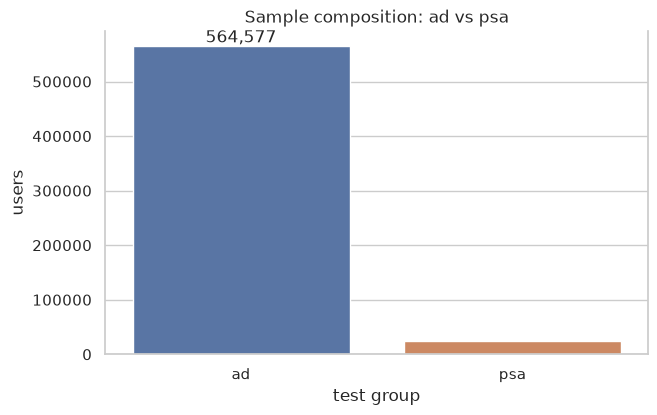

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
counts = df['test_group'].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, ax=ax, palette=['#4C72B0', '#DD8452'], legend=False)
ax.bar_label(ax.containers[0], fmt=lambda v: f'{v:,.0f}')
ax.set_title('Sample composition: ad vs psa')
ax.set_xlabel('test group'); ax.set_ylabel('users')
for s in ['top']: ax.spines[s].set_visible(False)

,test_group,users,converted,conversion_rate
0,ad,564577,14423,0.0255
1,psa,23524,420,0.0179


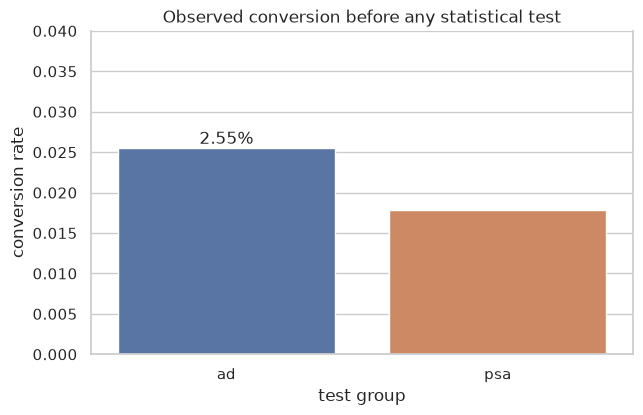

In [5]:
cr = conversion_rates(df)
display(cr)
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.barplot(x='test_group', y='conversion_rate', data=cr, hue='test_group', ax=ax, palette=['#4C72B0', '#DD8452'], legend=False)
ax.bar_label(ax.containers[0], fmt=lambda v: f'{v:.2%}')
ax.set_title('Observed conversion before any statistical test')
ax.set_xlabel('test group'); ax.set_ylabel('conversion rate')
ax.set_ylim(0, 0.04)
for s in ['top']: ax.spines[s].set_visible(False)

In [6]:
desc = describe_frame(df)
print('total_ads distribution:')
print(pd.Series(desc['total_ads_describe']).round(2).to_string())
print('\nmost_ads_day:')
print(pd.Series(desc['most_ads_day_counts']).sort_values(ascending=False).to_string())

total_ads distribution:
count   588101.0000
mean        24.8200
std         43.7200
min          1.0000
25%          4.0000
50%         13.0000
75%         27.0000
max       2065.0000

most_ads_day:
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479


## 4. Stage conclusion

- `unit of analysis` = user id; 588,101 rows = 588,101 users,
  no duplicates, no missing — no parsing needed.
- Groups are **heavily imbalanced**: psa is ~4% of the sample.
  Sample-size and power planning (Stage 4) must respect this ratio.
- Observed conversion is ad 2.55% vs psa 1.79% (**descriptive only** —
  no significance claimed before the pre-registered test).
- The `total_ads` spread (1–2065) and the `most_ads_day`/`most_ads_hour`
  columns are candidate confounders for the interpretation stage.
